In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

In [14]:
features = pd.read_csv(
    "../data/processed/features.csv",
    index_col=0,
    parse_dates=True
)

prices = pd.read_csv(
    "../data/processed/prices.csv",
    index_col=0,
    parse_dates=True
)

In [15]:
TRAIN_WINDOW = 1000

RETRAIN_FREQUENCY = 21

N_REGIMES = 3

predicted_regimes = []

prediction_dates = []

all_probabilities = []

In [16]:
for i in range(
    TRAIN_WINDOW,
    len(features),
    RETRAIN_FREQUENCY
):

    # ======================================
    # TRAIN / TEST SPLIT
    # ======================================

    train = features.iloc[
        i - TRAIN_WINDOW:i
    ]

    test = features.iloc[
        i:i + RETRAIN_FREQUENCY
    ]

    # ======================================
    # STANDARDIZE FEATURES
    # ======================================

    scaler = StandardScaler()

    scaled_train = scaler.fit_transform(
        train
    )

    scaled_test = scaler.transform(
        test
    )

    # ======================================
    # INITIALIZE HMM
    # ======================================

    model = GaussianHMM(
        n_components=N_REGIMES,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    # ======================================
    # TRAIN MODEL
    # ======================================

    model.fit(scaled_train)

    # ======================================
    # PREDICT REGIMES
    # ======================================

    preds = model.predict(
        scaled_test
    )

    probs = model.predict_proba(
        scaled_test
    )

    # ======================================
    # STORE OUTPUTS
    # ======================================

    predicted_regimes.extend(
        preds
    )

    prediction_dates.extend(
        test.index
    )

    all_probabilities.extend(
        probs
    )


Model is not converging.  Current: -7860.932000438033 is not greater than -7860.9320002340455. Delta is -2.0398783817654476e-07
Model is not converging.  Current: -12339.42974490314 is not greater than -12339.429340607483. Delta is -0.00040429565706290305
Model is not converging.  Current: -10283.038895849611 is not greater than -10283.037492797353. Delta is -0.0014030522579560056
Model is not converging.  Current: -10483.283957554377 is not greater than -10483.282584590324. Delta is -0.0013729640522797126
Model is not converging.  Current: -14651.187171628424 is not greater than -14651.186696910321. Delta is -0.000474718102850602
Model is not converging.  Current: -14817.775013049759 is not greater than -14817.774792762495. Delta is -0.00022028726380085573
Model is not converging.  Current: -14079.091465364752 is not greater than -14079.089445345073. Delta is -0.002020019679548568
Model is not converging.  Current: -13633.509217842236 is not greater than -13633.507639173327. Delta is 

In [17]:
walkforward_regimes = pd.Series(
    predicted_regimes,
    index=prediction_dates,
    name="Regime"
)


# ==========================================
# CREATE PROBABILITY DATAFRAME
# ==========================================

probability_df = pd.DataFrame(
    all_probabilities,
    index=prediction_dates
)

probability_df.columns = [
    f"Regime_{i}"
    for i in range(N_REGIMES)
]


In [18]:
walkforward_regimes.to_csv(
    "../data/processed/walkforward_regimes.csv"
)

probability_df.to_csv(
    "../data/processed/walkforward_probabilities.csv"
)

print("Walk-forward outputs saved.")


Walk-forward outputs saved.


In [19]:
print("\n" + "=" * 50)
print("REGIME DISTRIBUTION")
print("=" * 50)

print(
    walkforward_regimes.value_counts()
)


# ==========================================
# ALIGN PRICES
# ==========================================

aligned_prices = prices.loc[
    walkforward_regimes.index
]



REGIME DISTRIBUTION
Regime
0    956
1    782
2    655
Name: count, dtype: int64


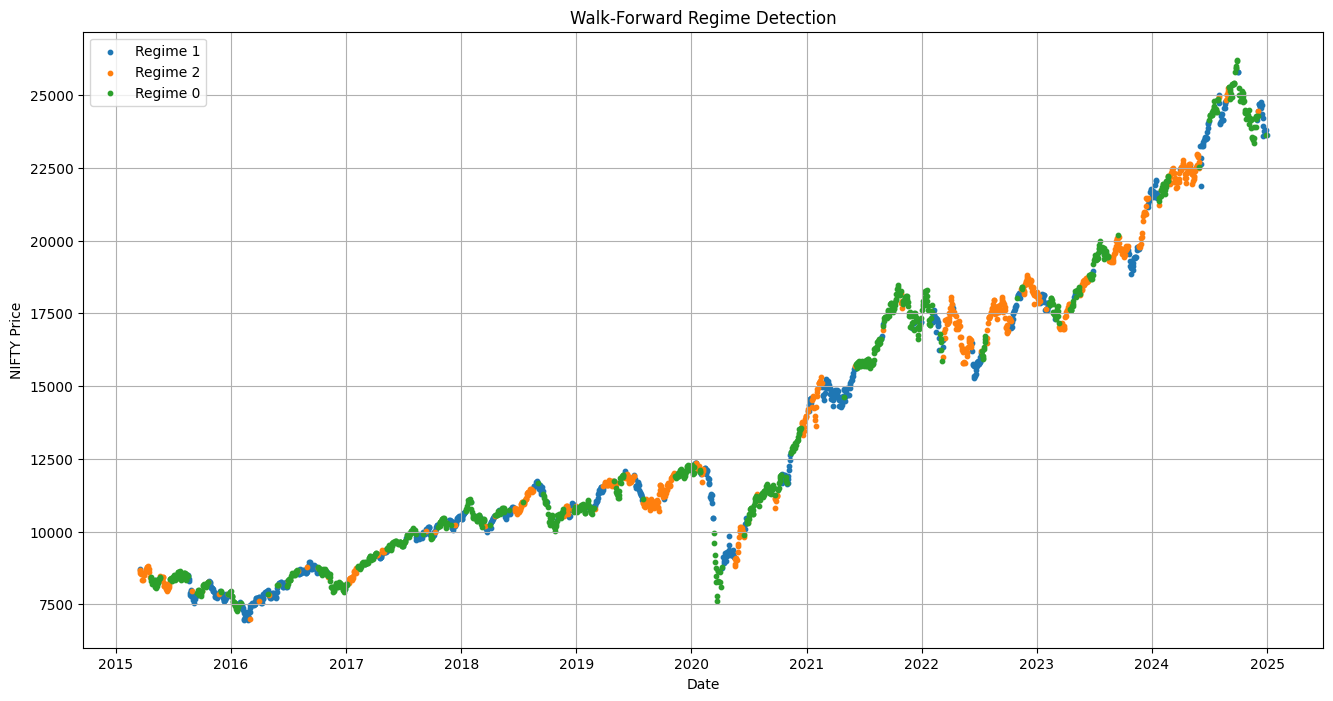

In [20]:
plt.figure(figsize=(16, 8))

for regime in walkforward_regimes.unique():

    mask = (
        walkforward_regimes == regime
    )

    plt.scatter(
        aligned_prices.index[mask],
        aligned_prices["^NSEI"][mask],
        label=f"Regime {regime}",
        s=10
    )

plt.legend()

plt.title(
    "Walk-Forward Regime Detection"
)

plt.xlabel("Date")

plt.ylabel("NIFTY Price")

plt.grid(True)

plt.savefig(
    "../reports/walkforward_regimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


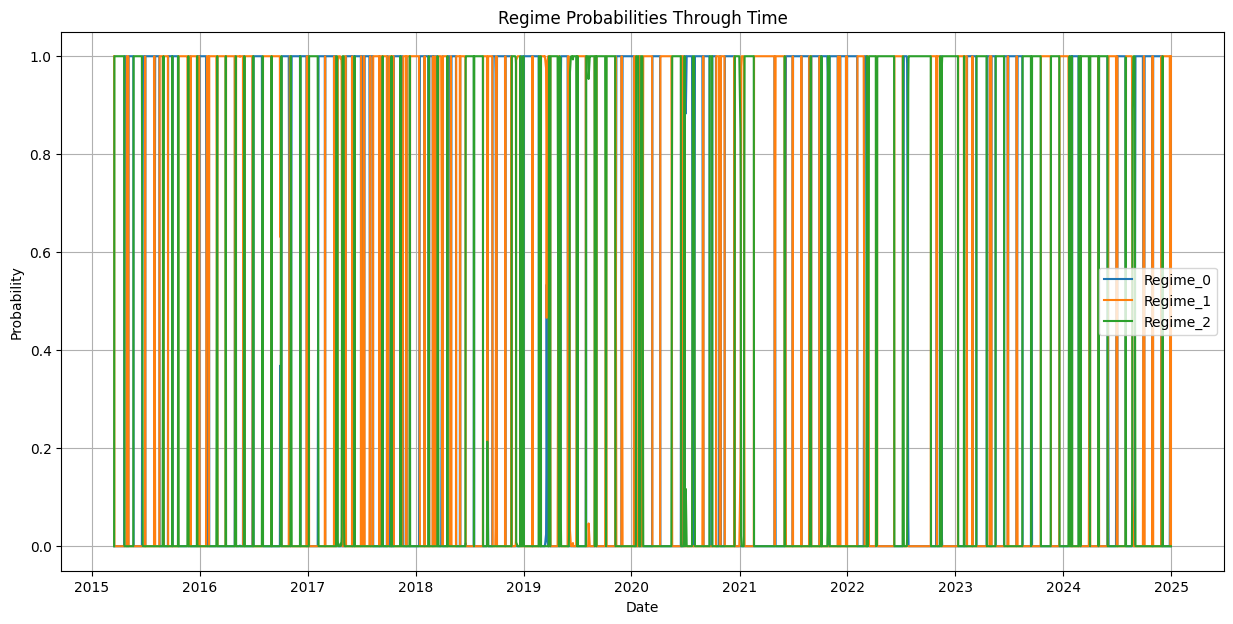

In [21]:
plt.figure(figsize=(15, 7))

for col in probability_df.columns:

    plt.plot(
        probability_df.index,
        probability_df[col],
        label=col
    )

plt.legend()

plt.title(
    "Regime Probabilities Through Time"
)

plt.xlabel("Date")

plt.ylabel("Probability")

plt.grid(True)

plt.savefig(
    "../reports/regime_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()